# Install Dependencies

In [46]:
!pip install kagglehub torch torchvision scikit-learn matplotlib seaborn pillow

# Import Libraries

In [47]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import kagglehub

print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.is_available())

PyTorch: 2.10.0+cu128
GPU: True


# Download Dataset 

In [48]:
dataset_path = kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset")
print("Downloaded at:", dataset_path)

Downloaded at: /kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset


# Clean Dataset (Remove Masks)

In [49]:
data_root = os.path.join(dataset_path, "Dataset_BUSI_with_GT")
classes = ["benign", "malignant", "normal"]

clean_dir = "busi_clean"

for c in classes:
    os.makedirs(os.path.join(clean_dir, c), exist_ok=True)

for c in classes:
    folder = os.path.join(data_root, c)
    for img in os.listdir(folder):
        if img.endswith(".png") and "_mask" not in img:
            shutil.copy(os.path.join(folder, img), os.path.join(clean_dir, c, img))

print("Dataset cleaned!")

Dataset cleaned!


# Train/Val/Test Split

In [50]:
base_dir = "busi_split"
train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

for d in [train_dir, val_dir, test_dir]:
    for c in classes:
        os.makedirs(os.path.join(d, c), exist_ok=True)

for c in classes:
    images = os.listdir(os.path.join(clean_dir, c))
    train_imgs, temp = train_test_split(images, test_size=0.3, random_state=42)
    val_imgs, test_imgs = train_test_split(temp, test_size=0.5, random_state=42)

    for img in train_imgs:
        shutil.copy(os.path.join(clean_dir, c, img), os.path.join(train_dir, c, img))
    for img in val_imgs:
        shutil.copy(os.path.join(clean_dir, c, img), os.path.join(val_dir, c, img))
    for img in test_imgs:
        shutil.copy(os.path.join(clean_dir, c, img), os.path.join(test_dir, c, img))

print("Split complete!")

Split complete!


# Transforms & Loaders

In [51]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = ImageFolder(train_dir, transform=train_transform)
val_dataset   = ImageFolder(val_dir, transform=test_transform)
test_dataset  = ImageFolder(test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16)

classes = train_dataset.classes

# Device + Class Weights

In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

counts = Counter(train_dataset.targets)
total = sum(counts.values())

class_weights = torch.tensor(
    [total / (len(classes) * counts[i]) for i in range(len(classes))],
    dtype=torch.float
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

# Depthwise CNN

In [53]:
class DepthwiseBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, in_c, 3, stride, 1, groups=in_c),
            nn.ReLU(),
            nn.Conv2d(in_c, out_c, 1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.block(x)

class DepthwiseCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1),
            nn.ReLU(),
            DepthwiseBlock(32, 64),
            DepthwiseBlock(64, 128, 2),
            DepthwiseBlock(128, 256, 2)
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(256, 3)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

# Models

In [54]:
resnet_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 3)
resnet_model = resnet_model.to(device)

dw_model = DepthwiseCNN().to(device)

# Training Function

In [55]:
def train_model(model, epochs=15):
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}: Loss = {total_loss:.4f}")

# Evaluation

In [56]:
def evaluate_model(model, model_name):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n{model_name} Results")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    }


def show_predictions(model, model_name, num_images=9):
    model.eval()

    indices = random.sample(range(len(test_dataset)), num_images)

    plt.figure(figsize=(12, 9))

    for i, idx in enumerate(indices):
        image, label = test_dataset[idx]

        with torch.no_grad():
            output = model(image.unsqueeze(0).to(device))
            _, pred = torch.max(output, 1)

        img = image.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        actual = classes[label]
        predicted = classes[pred.item()]

        color = "green" if actual == predicted else "red"

        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"A: {actual}\nP: {predicted}", color=color)

    plt.suptitle(f"Predictions — {model_name}")
    plt.tight_layout()
    plt.show()

# Train ResNet50

In [57]:
train_model(resnet_model)
resnet_acc = evaluate(resnet_model)

Epoch 1: Loss = 36.7104
Epoch 2: Loss = 24.6827
Epoch 3: Loss = 14.1105
Epoch 4: Loss = 8.1471
Epoch 5: Loss = 5.1699
Epoch 6: Loss = 4.7370
Epoch 7: Loss = 3.5207
Epoch 8: Loss = 3.6923
Epoch 9: Loss = 2.9963
Epoch 10: Loss = 1.7698
Epoch 11: Loss = 0.9228
Epoch 12: Loss = 1.5569
Epoch 13: Loss = 1.4972
Epoch 14: Loss = 0.6115
Epoch 15: Loss = 3.8009
Accuracy: 0.864406779661017
F1 Score: 0.8622754452663399


# Train Depthwise CNN

In [58]:
train_model(dw_model)
dw_acc = evaluate(dw_model)

Epoch 1: Loss = 38.6604
Epoch 2: Loss = 38.4848
Epoch 3: Loss = 38.4440
Epoch 4: Loss = 38.5120
Epoch 5: Loss = 38.3903
Epoch 6: Loss = 38.4571
Epoch 7: Loss = 38.3998
Epoch 8: Loss = 38.4063
Epoch 9: Loss = 38.4185
Epoch 10: Loss = 38.3712
Epoch 11: Loss = 38.4780
Epoch 12: Loss = 38.3912
Epoch 13: Loss = 38.4605
Epoch 14: Loss = 38.5121
Epoch 15: Loss = 38.4907
Accuracy: 0.559322033898305
F1 Score: 0.401252763448784


# Evaluate ResNet50 And Depthwise CNN


ResNet50 Results
Accuracy : 0.8644
Precision: 0.8654
Recall   : 0.8644
F1 Score : 0.8623


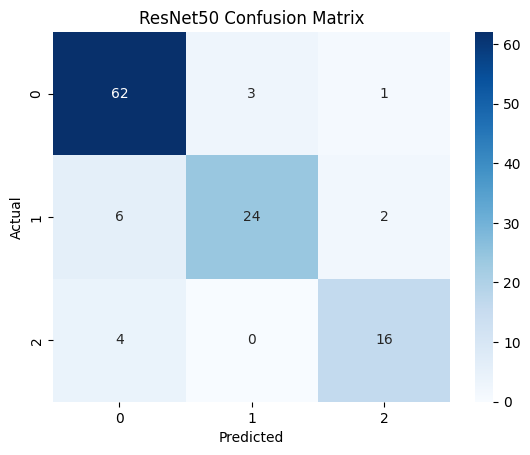

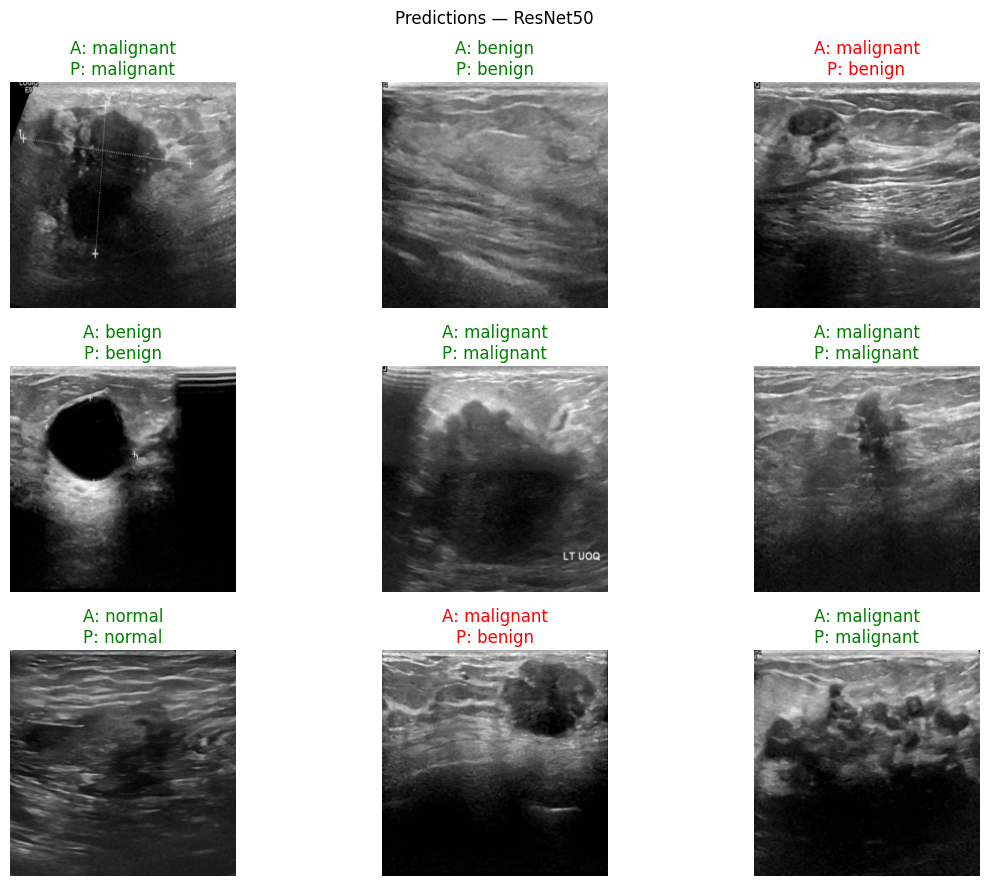


Depthwise CNN Results
Accuracy : 0.5593
Precision: 0.3128
Recall   : 0.5593
F1 Score : 0.4013


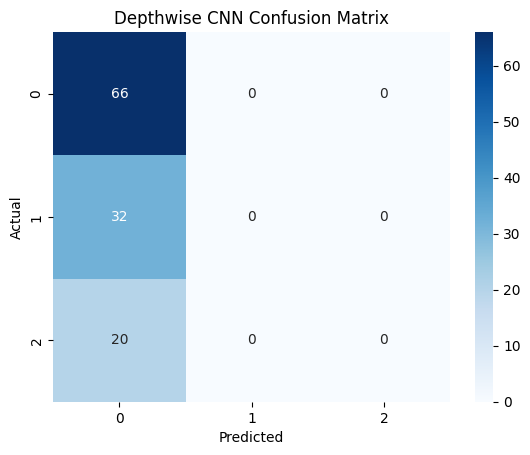

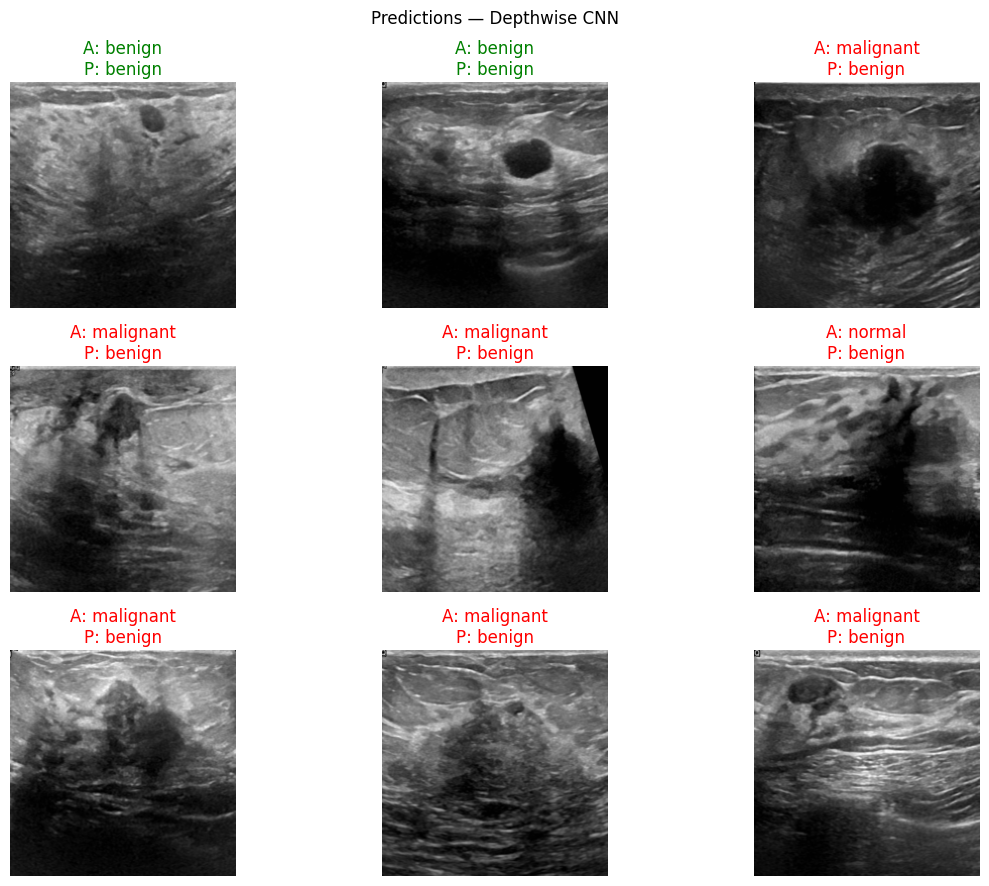

In [59]:
resnet_results = evaluate_model(resnet_model, "ResNet50")
show_predictions(resnet_model, "ResNet50")

dw_results = evaluate_model(dw_model, "Depthwise CNN")
show_predictions(dw_model, "Depthwise CNN")

# RESULTS TABLE

In [60]:
results = [resnet_results, dw_results]

print(f"{'Model':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1 Score':>10}")
print("-" * 62)
for r in results:
    print(f"{r['model']:<20} {r['accuracy']:>10.4f} {r['precision']:>10.4f} {r['recall']:>10.4f} {r['f1']:>10.4f}")

Model                  Accuracy  Precision     Recall   F1 Score
--------------------------------------------------------------
ResNet50                 0.8644     0.8654     0.8644     0.8623
Depthwise CNN            0.5593     0.3128     0.5593     0.4013


# BAR CHART

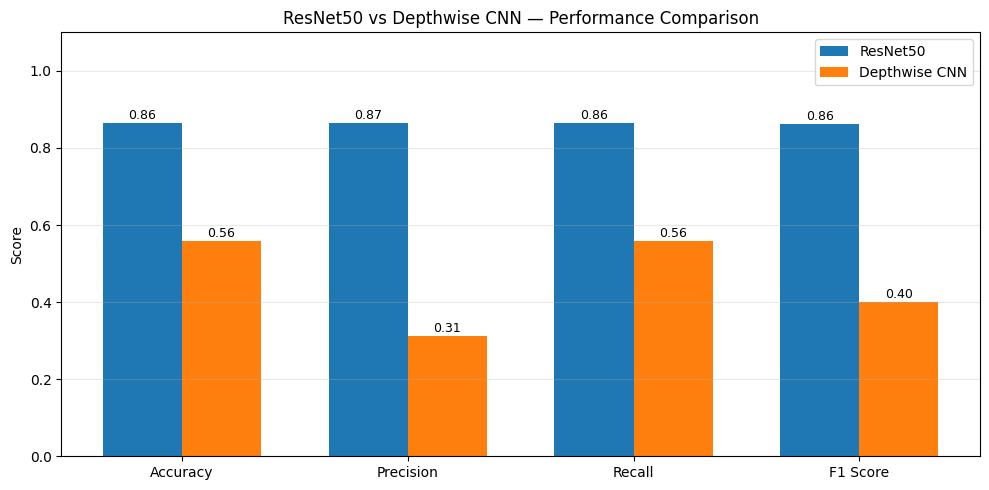

In [61]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

resnet_vals = [
    resnet_results['accuracy'],
    resnet_results['precision'],
    resnet_results['recall'],
    resnet_results['f1']
]

dw_vals = [
    dw_results['accuracy'],
    dw_results['precision'],
    dw_results['recall'],
    dw_results['f1']
]

x = np.arange(len(metrics))
w = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(x - w/2, resnet_vals, w, label='ResNet50')
bars2 = plt.bar(x + w/2, dw_vals, w, label='Depthwise CNN')

for bar in bars1 + bars2:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{bar.get_height():.2f}",
             ha='center', fontsize=9)

plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.ylabel("Score")
plt.title("ResNet50 vs Depthwise CNN — Performance Comparison")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# MODEL SIZE

In [62]:
resnet_params = sum(p.numel() for p in resnet_model.parameters())
dw_params     = sum(p.numel() for p in dw_model.parameters())

print("\nModel Size Comparison")
print(f"  ResNet50      : {resnet_params:>12,} parameters")
print(f"  Depthwise CNN : {dw_params:>12,} parameters")
print(f"  ResNet50 is {resnet_params/dw_params:.1f}x larger than Depthwise CNN")


Model Size Comparison
  ResNet50      :   23,514,179 parameters
  Depthwise CNN :       47,363 parameters
  ResNet50 is 496.5x larger than Depthwise CNN


# Comparison Graph

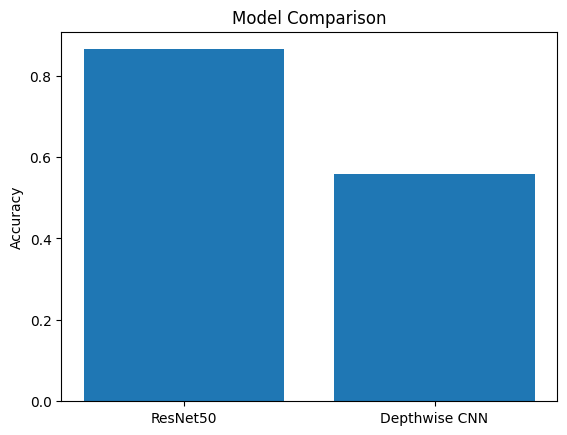

In [63]:
models = ["ResNet50", "Depthwise CNN"]
values = [resnet_acc, dw_acc]

plt.bar(models, values)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

# Save Models

In [64]:
torch.save(resnet_model.state_dict(), "resnet50.pth")
torch.save(dw_model.state_dict(), "depthwise_cnn.pth")